In [15]:
import sys
sys.path.append("..")
from src.data_utils import load_data, inspect_data
from src.features import select_features_target
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import pandas as pd

testing my load_data and inspect_data functions from utils.py

In [2]:
df = load_data("../data/raw/houses_small.csv")
inspect_data(df)


__head__
   Size  Bedrooms  Age  Distance_From_CBD  Price
0    60         1   10                  4    5.2
1    80         2    5                  6    6.0
2   100         2   12                  8    6.4
3   120         3    8                 10    7.0
4   150         3    3                 12    8.8
__shape__
(12, 5)
__info__
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Size               12 non-null     int64  
 1   Bedrooms           12 non-null     int64  
 2   Age                12 non-null     int64  
 3   Distance_From_CBD  12 non-null     int64  
 4   Price              12 non-null     float64
dtypes: float64(1), int64(4)
memory usage: 612.0 bytes
__describe__
             Size   Bedrooms        Age  Distance_From_CBD      Price
count   12.000000  12.000000  12.000000          12.000000  12.000000
mean   120.833333   2.666667   9.58

In [10]:
X, y = select_features_target(df, "Price")
print(X.shape)
print(y.shape)
print(X.columns)

(12, 4)
(12,)
Index(['Size', 'Bedrooms', 'Age', 'Distance_From_CBD'], dtype='str')


In [4]:
print(df.corr())

                       Size  Bedrooms       Age  Distance_From_CBD     Price
Size               1.000000  0.941159 -0.501859           0.948881  0.950254
Bedrooms           0.941159  1.000000 -0.508507           0.868544  0.943828
Age               -0.501859 -0.508507  1.000000          -0.621094 -0.482184
Distance_From_CBD  0.948881  0.868544 -0.621094           1.000000  0.822879
Price              0.950254  0.943828 -0.482184           0.822879  1.000000


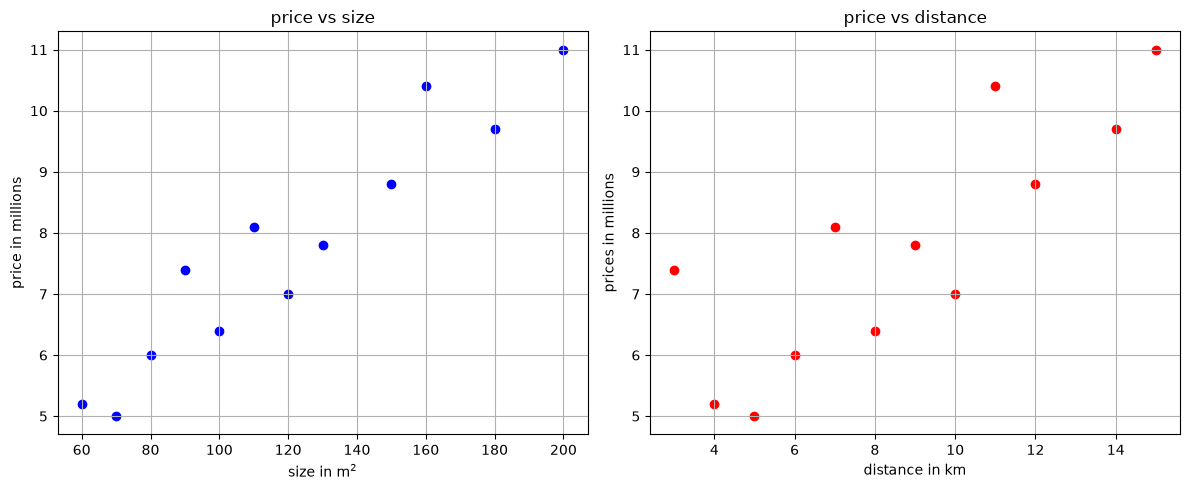

In [7]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

axes[0].scatter(df["Size"], df["Price"], color="blue")
axes[0].set_xlabel("size in m$^2$")
axes[0].set_ylabel("price in millions")
axes[0].set_title("price vs size")
axes[0].grid(True)

axes[1].scatter(df["Distance_From_CBD"], df["Price"], color="red")
axes[1].set_xlabel("distance in km")
axes[1].set_ylabel("prices in millions")
axes[1].set_title("price vs distance")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [8]:
print(df[df["Distance_From_CBD"]== 3])

   Size  Bedrooms  Age  Distance_From_CBD  Price
5    90         2   20                  3    7.4


In [17]:
model = LinearRegression()
model.fit(X, y)
print(f" intercept: {model.intercept_:.4f}\n")
coef_df =pd.DataFrame( {
    "Features": model.feature_names_in_,
    "coefficient": model.coef_

})
print(coef_df)

 intercept: 3.1912

            Features  coefficient
0               Size     0.075558
1           Bedrooms     0.260904
2                Age    -0.069221
3  Distance_From_CBD    -0.533107


In [ ]:
import numpy as np
X = np.array([1,2,3])
y = np.array([50, 60, 85])
x_mean = np.mean(X)
y_mean = np.mean(y)
numerator = np.sum((X-x_mean)*(y-y_mean))
denominator = np.sum((X-x_mean)**2)
slope = numerator/denominator
intercept = y_mean -(slope*x_mean)
print(slope)
print(intercept)

model = LinearRegres

17.5
30.0
